<a href="https://colab.research.google.com/github/dgonzales1222/greends_avcad_exercises/blob/main/exercise_03/CaseStudy1_univariate_analysis_visuals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advance Visualization of Complex Agro-environmental Data

# **Exercise 3: Univariate Analysis of Annual Mean Temperature**

Danilo III O. Gonzales (29225) <br>
Master's in Green Data Science

### AI Use Declaration and Prompts Used

I acknowledge that I used **Gemini Pro** as an AI tool provided under my university access to assist in the preparation of this work. All AI-generated suggestions were carefully reviewed, edited, and verified by me to ensure accuracy, originality, and compliance with university academic integrity policies. The prompts used during this process included:

- `Can I use the Github link of the zip file to access it in Colab?`

I take full responsibility for the final submitted work and confirm that the use of AI aligns with the guidelines established by the university. I am also willing to provide the full AI conversation transcript upon request for transparency and verification purposes.

# Case Study 1: Univariate Analysis Visuals
---
## Descriptive statistics

As an example we will work on a subset of a database that resulted from integrating information from several river fish biomonitoring programmes accross Europe. This subset includes data for some Mediterranean countries. Each case (rows) corresponds to a fish sampling point. Variables (columns) includes coordinates, country and catchment identifiers, local scale environmental variables, climatic variables, human pressures and fish presence/absence data.

When working with a new dataset, one of the most useful things to do is to begin to visualize the data. By using tables, histograms, box plots, and other visual tools, we can get a better idea of what the data may be trying to tell us, and we can gain insights into the data that we may have not discovered otherwise.

We will be going over how to perform some basic visualisations in Python, and, most importantly, we will learn how to begin exploring data from a graphical perspective.

In [ ]:
import pandas as pd
import zipfile
import seaborn as sns # For plotting
import matplotlib.pyplot as plt # For showing plots
import numpy as np

#### Import, visualize and summarize table properties

First, we will download the `EFIplus_medit.zip` file from the provided GitHub link.

In [ ]:
import requests

github_zip_url = "https://github.com/dgonzales1222/greends_avcad_exercises/raw/main/exercise_03/EFIplus_medit.zip"
output_filename = "EFIplus_medit.zip"

response = requests.get(github_zip_url)
response.raise_for_status() # Raise an exception for HTTP errors

with open(output_filename, "wb") as f:
    f.write(response.content)

print(f"Downloaded {output_filename} successfully.")

Downloaded EFIplus_medit.zip successfully.


In [ ]:
df = pd.read_csv('EFIplus_medit.zip', compression='zip', sep=';')
print(df)

       Site_code   Latitude  Longitude   Country Catchment_name  Galiza  \
0     ES_01_0002  38.102003  -4.096070     Spain   Guadalquivir       0   
1     ES_02_0001  40.530188  -1.887796     Spain           Tejo       0   
2     ES_02_0002  40.595432  -1.928079     Spain           Tejo       0   
3     ES_02_0003  40.656184  -1.989831     Spain           Tejo       0   
4     ES_02_0004  40.676402  -2.036274     Spain           Tejo       0   
...          ...        ...        ...       ...            ...     ...   
5006      PTVO60  40.641612  -8.325149  Portugal          Vouga       0   
5007      PTVO61  40.729015  -8.098851  Portugal          Vouga       0   
5008      PTVO62  40.727959  -8.107344  Portugal          Vouga       0   
5009      PTVO63  40.817783  -8.224903  Portugal          Vouga       0   
5010      PTVO64  40.794352  -8.255380  Portugal          Vouga       0   

      Subsample  Calib_EFI_Medit  Calib_connect  Calib_hydrol  ...  \
0             1              

In [ ]:
df.head(5)

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5011 entries, 0 to 5010
Columns: 164 entries, Site_code to Iberochondrostoma_sp
dtypes: float64(38), int64(120), object(6)
memory usage: 6.3+ MB


In [ ]:
list(df.columns)

['Site_code',
 'Latitude',
 'Longitude',
 'Country',
 'Catchment_name',
 'Galiza',
 'Subsample',
 'Calib_EFI_Medit',
 'Calib_connect',
 'Calib_hydrol',
 'Calib_morphol',
 'Calib_wqual',
 'Geomorph1',
 'Geomorph2',
 'Geomorph3',
 'Water_source_type',
 'Flow_regime',
 'Altitude',
 'Geological_typology',
 'Actual_river_slope',
 'Natural_sediment',
 'Elevation_mean_catch',
 'prec_ann_catch',
 'temp_ann',
 'temp_jan',
 'temp_jul',
 'Barriers_catchment_down',
 'Barriers_river_segment_up',
 'Barriers_river_segment_down',
 'Barriers_number_river_segment_up',
 'Barriers_number_river_segment_down',
 'Barriers_distance_river_segment_up',
 'Barriers_distance_river_segment_down',
 'Impoundment',
 'Hydropeaking',
 'Water_abstraction',
 'Hydro_mod',
 'Temperature_impact',
 'Velocity_increase',
 'Reservoir_flushing',
 'Sedimentation',
 'Channelisation',
 'Cross_sec',
 'Instream_habitat',
 'Riparian_vegetation',
 'Embankment',
 'Floodprotection',
 'Floodplain',
 'Toxic_substances',
 'Acidification',
 '

#### Clean and reajust the dataset

In [ ]:
# clean up the dataset to remove unnecessary columns (eg. REG)
df.drop(df.iloc[:,5:15], axis=1, inplace=True) # axis=1 - columns; inplace=True - the changes will be saved to the original data frame.

# let's rename some columns so that they make sense
df.rename(columns={'Sum of Run1_number_all':'Total_fish_individuals'}, inplace=True) # inplace="True" means that df will be updated

# for consistency, let's also make all column labels of type string
df.columns = list(map(str, df.columns))

In [ ]:
# Check data types
pd.options.display.max_rows = 154 # maximum number of rows displayed.
df.dtypes

,0
Site_code,object
Latitude,float64
Longitude,float64
Country,object
Catchment_name,object
Water_source_type,object
Flow_regime,object
Altitude,int64
Geological_typology,object
Actual_river_slope,float64


In [ ]:
# Number of values per variable
df.count()

,0
Site_code,5011
Latitude,5011
Longitude,5011
Country,5011
Catchment_name,5011
Water_source_type,4712
Flow_regime,4473
Altitude,5011
Geological_typology,5011
Actual_river_slope,4975


### Handling missing data

In [ ]:
# Number of missing values (NaN) per variable
df.isnull().sum()

,0
Site_code,0
Latitude,0
Longitude,0
Country,0
Catchment_name,0
Water_source_type,299
Flow_regime,538
Altitude,0
Geological_typology,0
Actual_river_slope,36


Let's drop the rows (records or observations) that contains at least one missing value (this is the default of the dropna method - other inactive examples are given below).

In [ ]:
df2 = df.dropna() # drops rows when at least one element is a missing value
df2.info()

#df2 = df.dropna(how='all') # drops rows when all elements are missing values
#df2.info()

#df2 = df.dropna(how='all', axis=1) # drops columns when at least one element is a missing value
#df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2822 entries, 18 to 5010
Columns: 154 entries, Site_code to Iberochondrostoma_sp
dtypes: float64(35), int64(113), object(6)
memory usage: 3.3+ MB


### Numerical summaries

In [ ]:
# mean and median (rounded to 2 decimal cases)
mean = round(df2['prec_ann_catch'].mean(), 2)
median = round(df2['prec_ann_catch'].median(), 2)
print(mean, median)

1069.98 1074.66


In [ ]:
# the catchment with more data
print(df2['Catchment_name'].mode())

0    Galiza-Norte
Name: Catchment_name, dtype: object


In [ ]:
# A fast way of getting a summary statistics of quantitative data (int or float)

# before dropping NaNs (rounded to 2 decimal cases)
round(df.describe() ,2)

,Latitude,Longitude,Altitude,Actual_river_slope,Natural_sediment,Elevation_mean_catch,prec_ann_catch,temp_ann,temp_jan,temp_jul,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
count,5011.00,5011.00,5011.00,4975.00,4402.00,4841.00,4841.00,4841.00,4841.00,4841.00,...,5011.00,5011.00,5011.00,5011.00,5011.00,5011.00,5011.0,5011.00,5011.00,5011.00
mean,41.66,-4.22,428.07,14.58,3.06,785.18,941.82,13.26,6.21,20.60,...,0.00,0.09,0.00,0.00,0.01,0.00,0.2,0.07,0.13,0.03
std,1.65,4.75,342.91,22.60,0.57,432.73,292.50,2.17,2.66,2.58,...,0.02,0.28,0.02,0.02,0.11,0.01,0.4,0.25,0.34,0.17
min,36.21,-9.46,0.00,0.00,1.00,52.25,373.37,3.90,-2.70,11.90,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00
25%,40.45,-7.72,142.00,3.51,3.00,468.39,677.47,12.00,4.30,18.80,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00
50%,42.32,-6.18,375.00,8.00,3.00,701.44,968.90,13.40,6.40,20.10,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00
75%,42.90,-1.96,610.50,17.17,3.00,1049.98,1168.36,14.60,8.30,22.50,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00
max,45.10,15.63,1851.00,774.00,4.00,2545.55,1739.00,18.30,12.50,28.20,...,1.00,1.00,1.00,1.00,1.00,1.00,1.0,1.00,1.00,1.00


In [ ]:
# after dropping NaNs (rounded to 2 decimal cases)
round(df2.describe() ,2)

,Latitude,Longitude,Altitude,Actual_river_slope,Natural_sediment,Elevation_mean_catch,prec_ann_catch,temp_ann,temp_jan,temp_jul,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
count,2822.00,2822.00,2822.00,2822.00,2822.00,2822.00,2822.00,2822.00,2822.00,2822.00,...,2822.0,2822.00,2822.00,2822.0,2822.00,2822.0,2822.00,2822.00,2822.00,2822.00
mean,41.93,-6.71,344.70,15.36,3.11,668.77,1069.98,13.43,7.04,19.92,...,0.0,0.08,0.00,0.0,0.00,0.0,0.25,0.04,0.09,0.03
std,1.58,3.20,291.16,24.16,0.62,371.26,250.83,1.91,2.44,2.02,...,0.0,0.27,0.03,0.0,0.02,0.0,0.44,0.20,0.29,0.18
min,36.87,-9.46,1.00,0.00,1.00,52.25,456.28,6.70,-0.20,14.70,...,0.0,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00
25%,41.21,-8.23,94.00,3.99,3.00,382.21,922.39,12.40,5.30,18.50,...,0.0,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00
50%,42.54,-7.56,292.00,8.80,3.00,590.00,1074.66,13.50,7.30,19.50,...,0.0,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00
75%,43.08,-6.73,502.75,18.23,3.00,890.28,1246.04,14.60,8.90,21.00,...,0.0,0.00,0.00,0.0,0.00,0.0,1.00,0.00,0.00,0.00
max,43.70,15.51,1440.00,774.00,4.00,2003.13,1739.00,17.50,11.90,25.70,...,0.0,1.00,1.00,0.0,1.00,0.0,1.00,1.00,1.00,1.00


In [ ]:
# Retrieving the number of observation for each category of a categorical variable (eg. Country)
country_count = pd.crosstab(index = df2['Country'], columns='count')
print(country_count)

col_0     count
Country        
Italy        51
Portugal    866
Spain      1905


In [ ]:
# Retrieving the number of observation for each catchment
catchment_count = pd.crosstab(index = df2['Catchment_name'], columns='count')
print(catchment_count)

col_0                  count
Catchment_name              
Algarve-Sotavento          6
Algarve-barlavento        10
Campania-South             5
Cantabrica               345
Catala                     2
Douro                    272
Ebro                      61
EntreDouroeVouga           2
Galiza-Norte             702
Galiza-Sul                95
Guadalquivir               1
Guadia                   102
Jucar                      4
Minho                    699
Mira                       5
Mondego                   86
Odelouca                  40
Oeste                     33
Sado                       9
Saline-Pescara-Sangro      1
Segura                     2
Sur                        2
Tejo                     235
Tejo-Sado                  1
Tevere                    45
Vouga                     56
Vouga-Mondego              1


### Plotting qualitative data

Check here: https://seaborn.pydata.org/generated/seaborn.catplot.html

##### Barplots (categorical plots)

Plotting the number of sites per country

In [ ]:
country_count.index

Index(['Italy', 'Portugal', 'Spain'], dtype='object', name='Country')

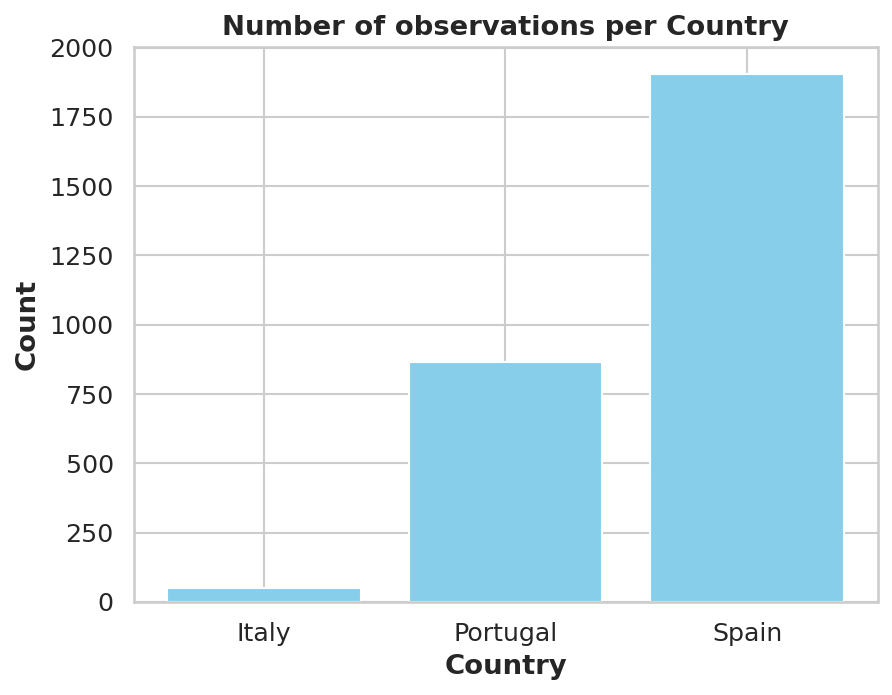

In [ ]:
# Using matplotlib
# Plot a bar chart using the country counts, setting the bar color to sky blue
plt.bar(country_count.index, country_count['count'], color='skyblue')

# Set the label for the x-axis
plt.xlabel('Country')

# Set the label for the y-axis
plt.ylabel('Count')

# Set the title of the plot
plt.title('Number of observations per Country')

# Display the plot on the screen
plt.show()

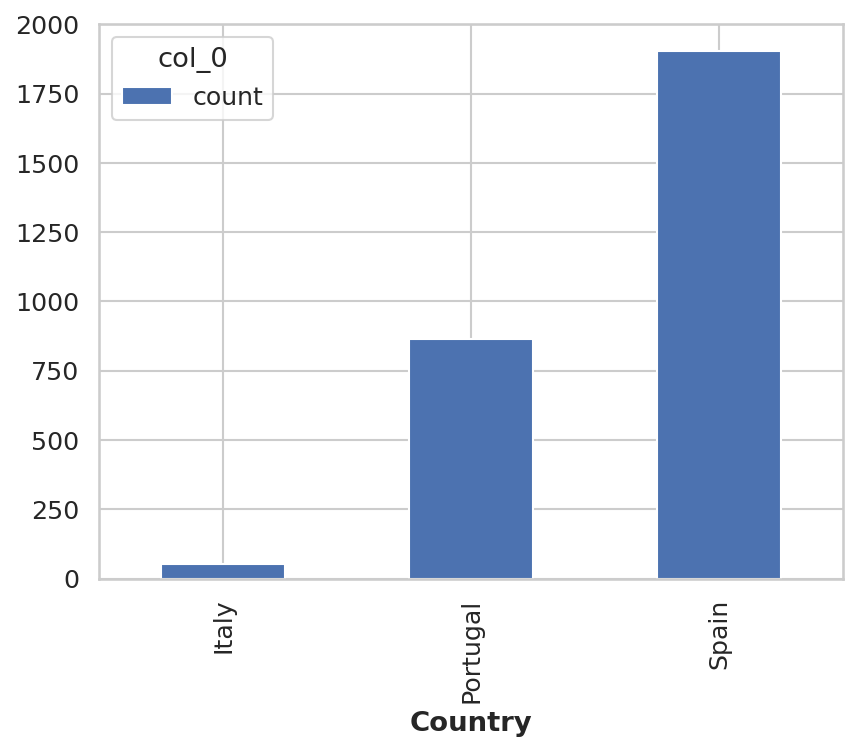

In [ ]:
# using pandas 'plot' method
country_count.plot(kind='bar')
plt.show()

In [ ]:
# getting help on the 'plot' method
help(country_count.plot)

Help on PlotAccessor in module pandas.plotting._core object:

class PlotAccessor(pandas.core.base.PandasObject)
 |  PlotAccessor(data: 'Series | DataFrame') -> 'None'
 |
 |  Make plots of Series or DataFrame.
 |
 |  Uses the backend specified by the
 |  option ``plotting.backend``. By default, matplotlib is used.
 |
 |  Parameters
 |  ----------
 |  data : Series or DataFrame
 |      The object for which the method is called.
 |  x : label or position, default None
 |      Only used if data is a DataFrame.
 |  y : label, position or list of label, positions, default None
 |      Allows plotting of one column versus another. Only used if data is a
 |      DataFrame.
 |  kind : str
 |      The kind of plot to produce:
 |
 |      - 'line' : line plot (default)
 |      - 'bar' : vertical bar plot
 |      - 'barh' : horizontal bar plot
 |      - 'hist' : histogram
 |      - 'box' : boxplot
 |      - 'kde' : Kernel Density Estimation plot
 |      - 'density' : same as 'kde'
 |      - 'area' 

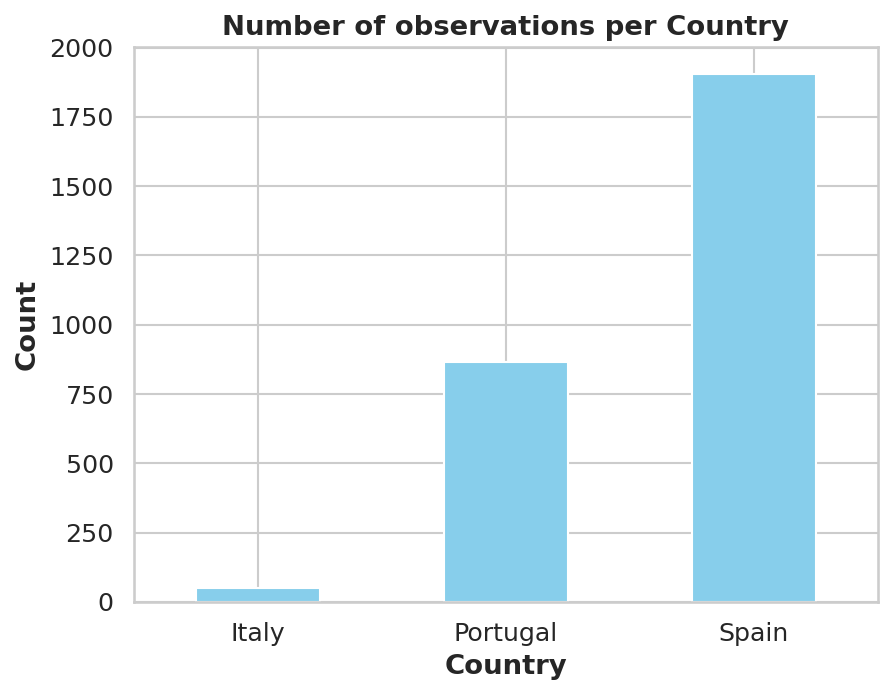

In [ ]:
# Fine tuning pandas 'plot' method
country_count.plot(kind='bar',
                   legend=False,
                   color='skyblue',
                   title='Number of observations per Country',
                   xlabel='Country',
                   ylabel='Count',
                   rot=0) # rot=0 - rotation of x labels
plt.show()

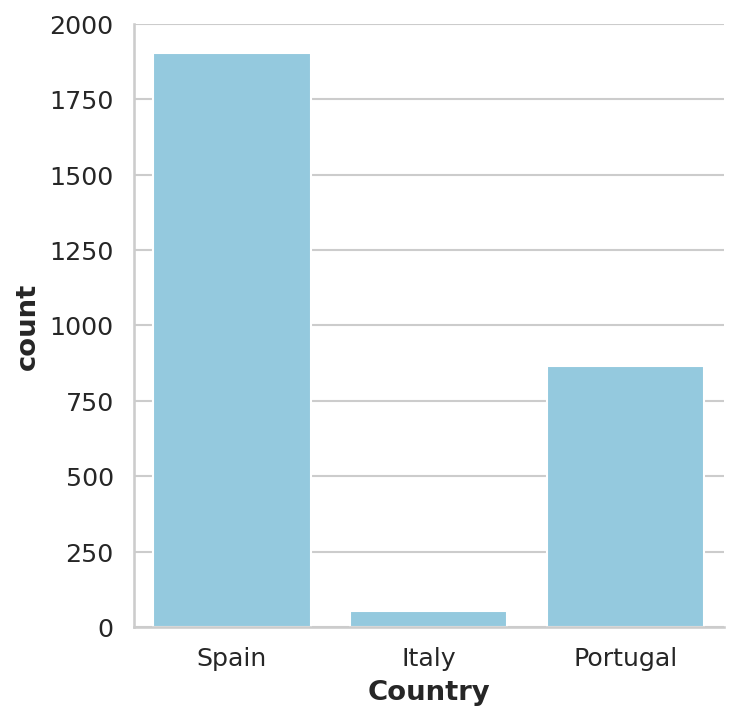

In [ ]:
# Now using seaborn
sns.catplot(x="Country", data=df2, kind="count", color="skyblue")
plt.show()

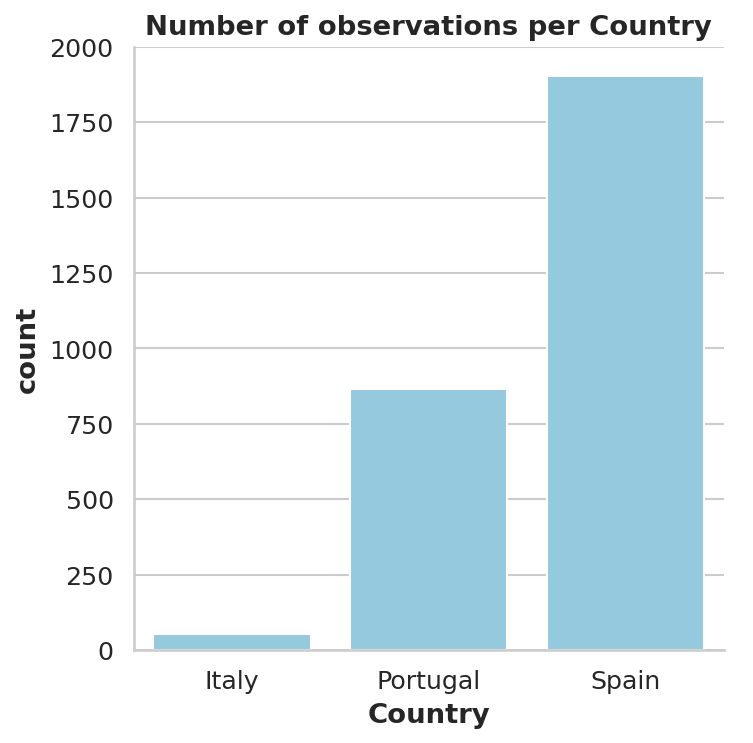

In [ ]:
# Same thing but now changing the order and including a title:
sns.catplot(x="Country", data=df2, kind="count", color="skyblue", order=['Italy', 'Portugal', 'Spain']).set(title='Number of observations per Country')
plt.show()

# Another way of including a title:
# ax = sns.catplot(x="Country", data=df, kind="count", color="skyblue", order=['Italy', 'Portugal', 'Spain'])
# ax.set_titles('Number of observations per Country')
# plt.show()

Plotting the number of sites per catchment

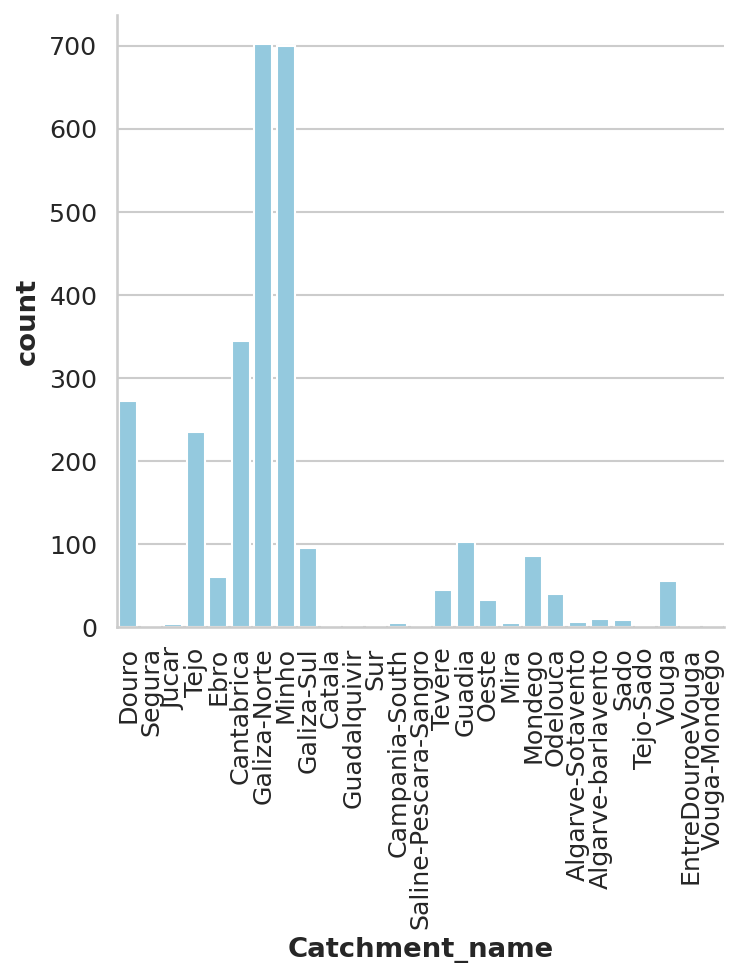

In [ ]:
# using Seaborn
sns.catplot(x="Catchment_name", data=df2, kind="count", color="skyblue")
plt.xticks(rotation=90)
plt.show()

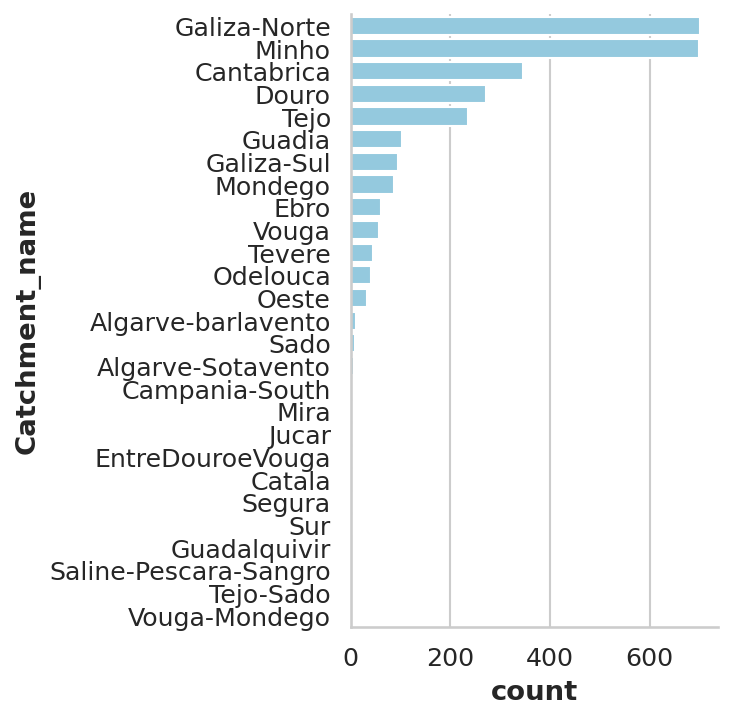

In [ ]:
# Same thing but in a decreasing order:
order = df2["Catchment_name"].value_counts().index # the order of the categories is defined by the number of observations (decreasing order)

sns.catplot(y="Catchment_name", data=df2, kind="count", color="skyblue", order=order, orient="h")
plt.xticks()
plt.show()

##### Pie charts

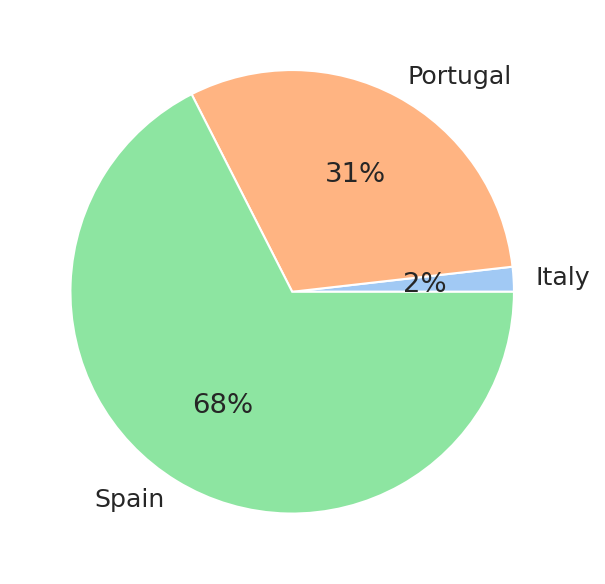

In [ ]:
# pie chart
colors = sns.color_palette('pastel')
labels = list(country_count.index) # list of country names
plt.pie(list(country_count.iloc[:,0]), labels=labels, colors = colors, autopct = '%0.0f%%')
plt.show()

##### Treemaps

To plot treemaps you'll need to install `squarify`: run `pip install squarify` in the terminal.

In [ ]:
!pip install -q squarify

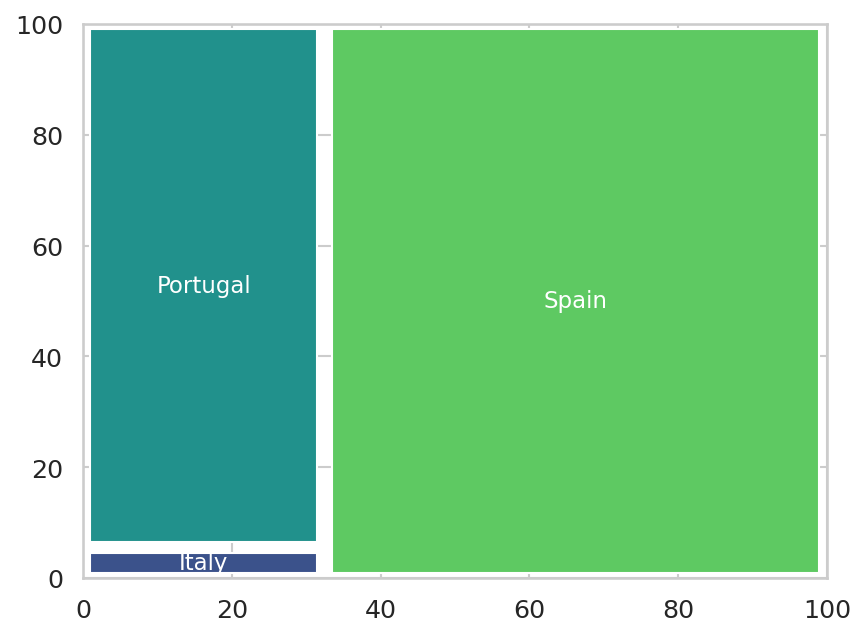

In [ ]:
import squarify as sqrf

labels = list(country_count.index) # list of country names

sqrf.plot(sizes=list(country_count.iloc[:,0]), # select all rows from the 1st column of data
          label=labels, # names of countries
          color=sns.color_palette('viridis',n_colors=len(labels)), # color palette
          text_kwargs={'fontsize': 11, 'color':"white"}, # label format
          pad=0.25) # define space between areas
plt.show()


### Plotting quantitative data

#### Strip plots
check here: https://seaborn.pydata.org/generated/seaborn.stripplot.html

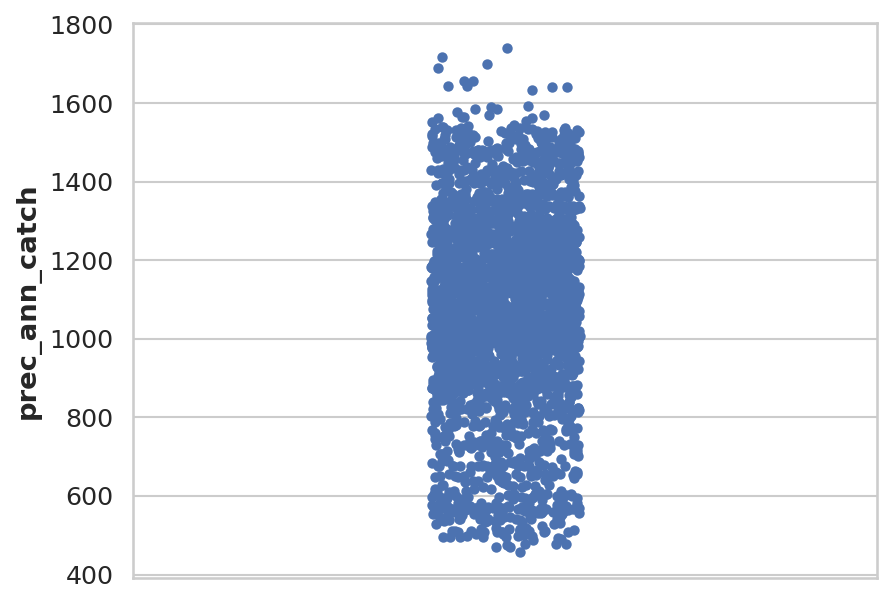

In [ ]:
# plot the mean annual total precipitation in the upstream catchment of each site
sns.stripplot(df2['prec_ann_catch'])
plt.show()


#### Histograms
check here: https://seaborn.pydata.org/generated/seaborn.histplot.html

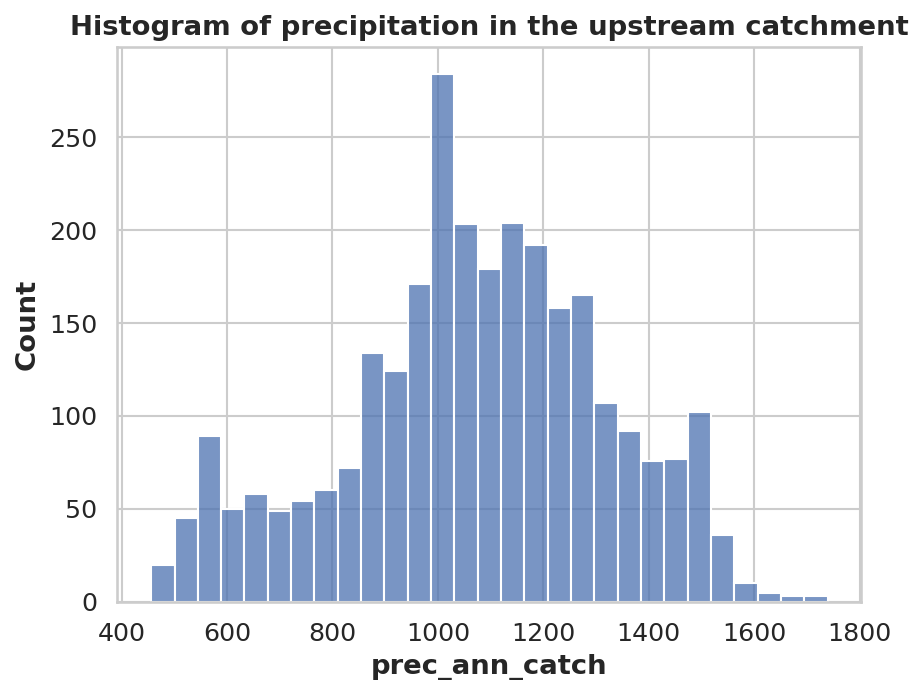

In [ ]:
# histogram of the mean annual total precipitation in the upstream catchment of each site
sns.histplot(df2['prec_ann_catch'], kde = False).set_title("Histogram of precipitation in the upstream catchment")
plt.show()

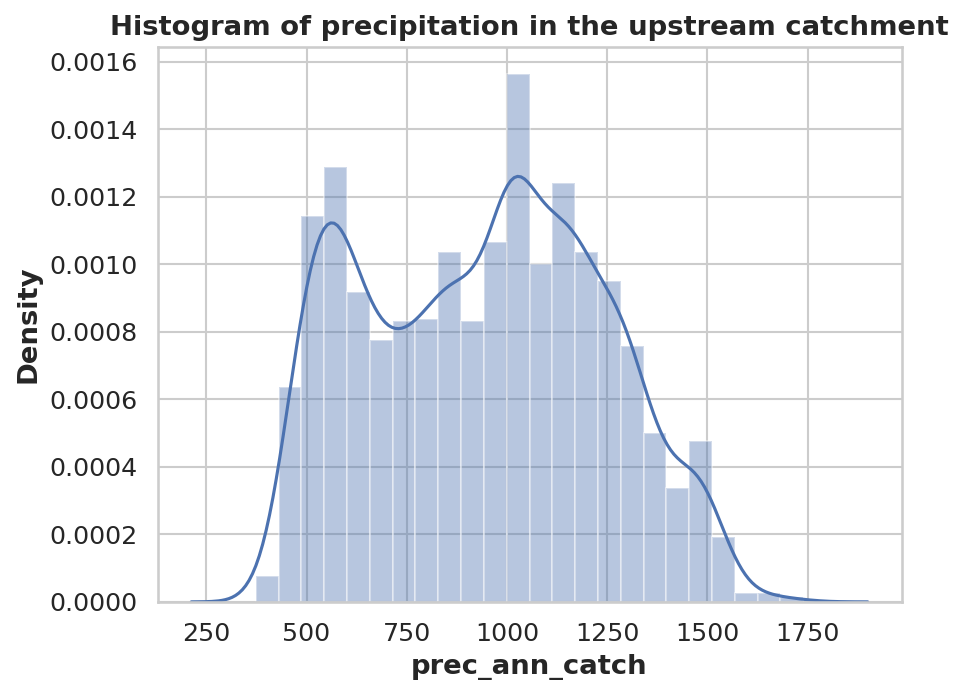

In [ ]:
# More variations
sns.histplot(
    df["prec_ann_catch"],
    kde=True,
    stat="density", # plot proportions instead of frequencies
    kde_kws=dict(cut=3),
    alpha=.4, # transparency
    edgecolor=(1, 1, 1, 0.4), # bar contour lines (r, g, b, alpha)
).set_title("Histogram of precipitation in the upstream catchment")
plt.show()

### Bar plots

Check here: https://seaborn.pydata.org/generated/seaborn.barplot.html

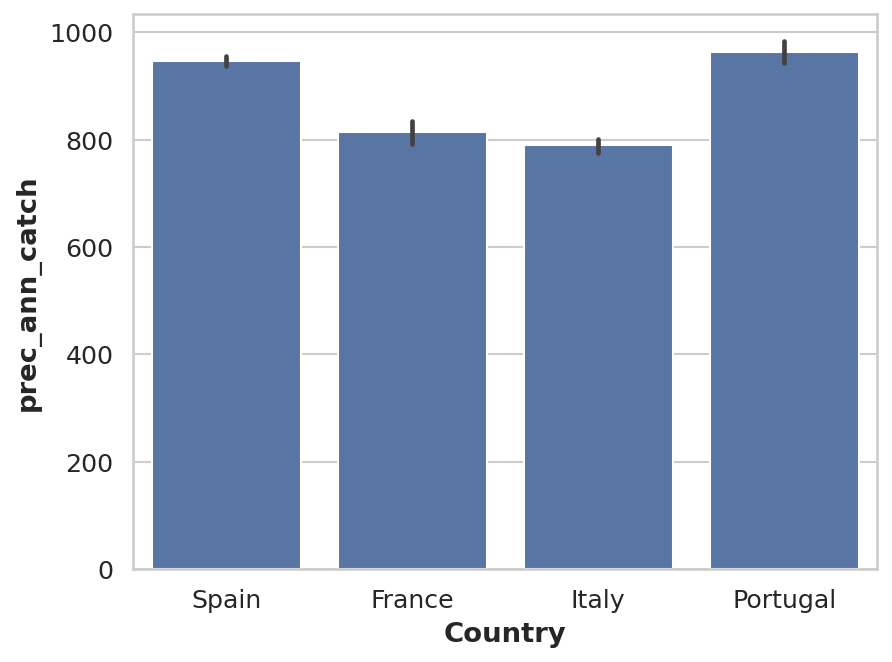

In [ ]:
# bar plot of Total Annual Precipitation by country
sns.barplot(x="Country", y="prec_ann_catch", data=df)
plt.show()

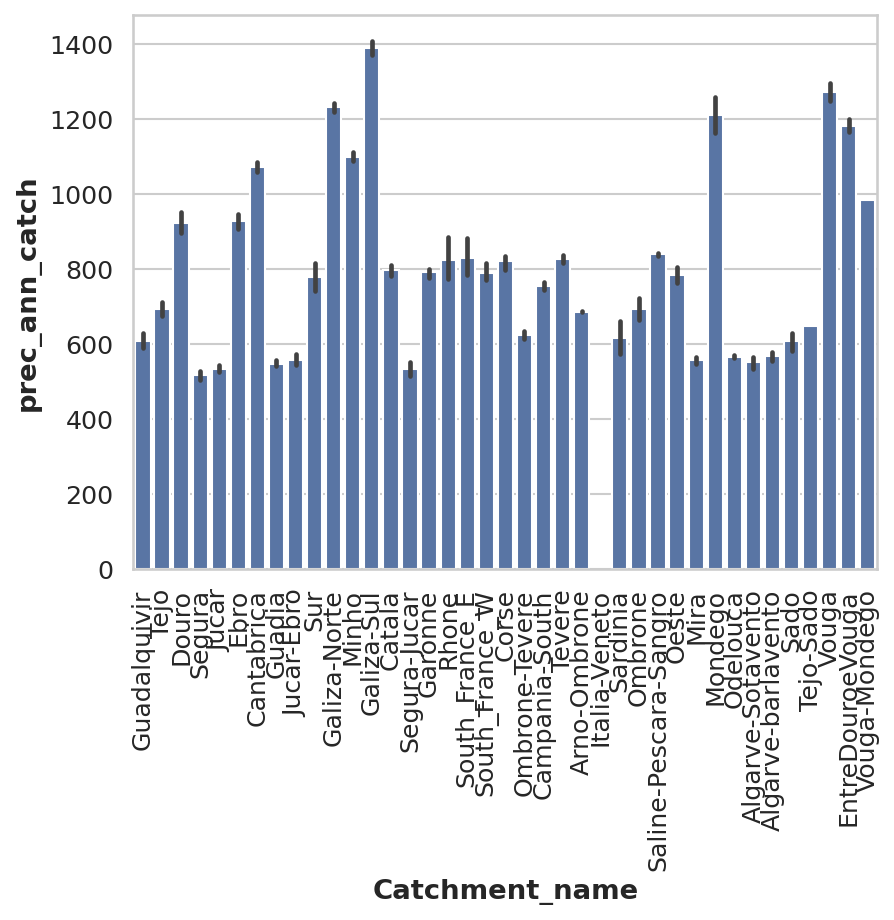

In [ ]:
# bar plot of Total Annual Precipitation by catchment
sns.barplot(data=df, x="Catchment_name", y="prec_ann_catch")
plt.xticks(rotation=90)
plt.show()

### Boxplots

Check here: https://seaborn.pydata.org/generated/seaborn.boxplot.html

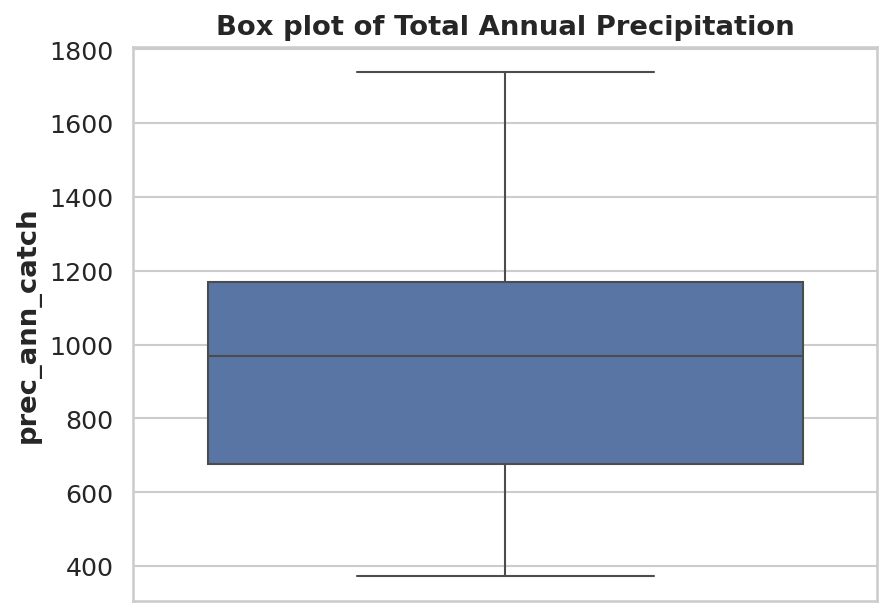

In [ ]:
# Box plot of Total Annual Precipitation
sns.boxplot(df["prec_ann_catch"]).set_title("Box plot of Total Annual Precipitation")
plt.show()

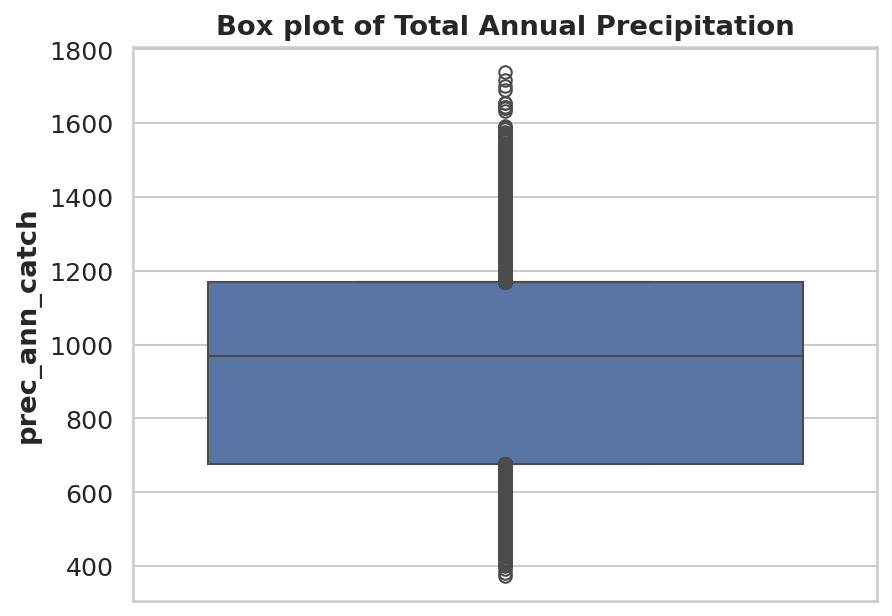

In [ ]:
# no whiskers (data points outside the box instead)
sns.boxplot(df["prec_ann_catch"], whis=0).set_title("Box plot of Total Annual Precipitation")
plt.show()

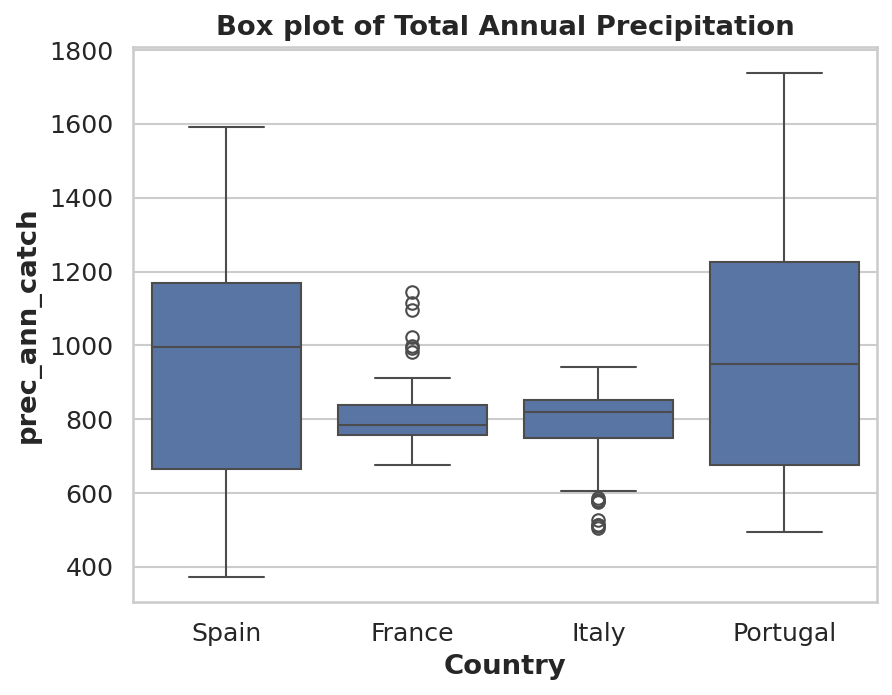

In [ ]:
# Box plot of Total Annual Precipitation by country
sns.boxplot(x="Country", y="prec_ann_catch", data=df).set_title("Box plot of Total Annual Precipitation")
plt.show()

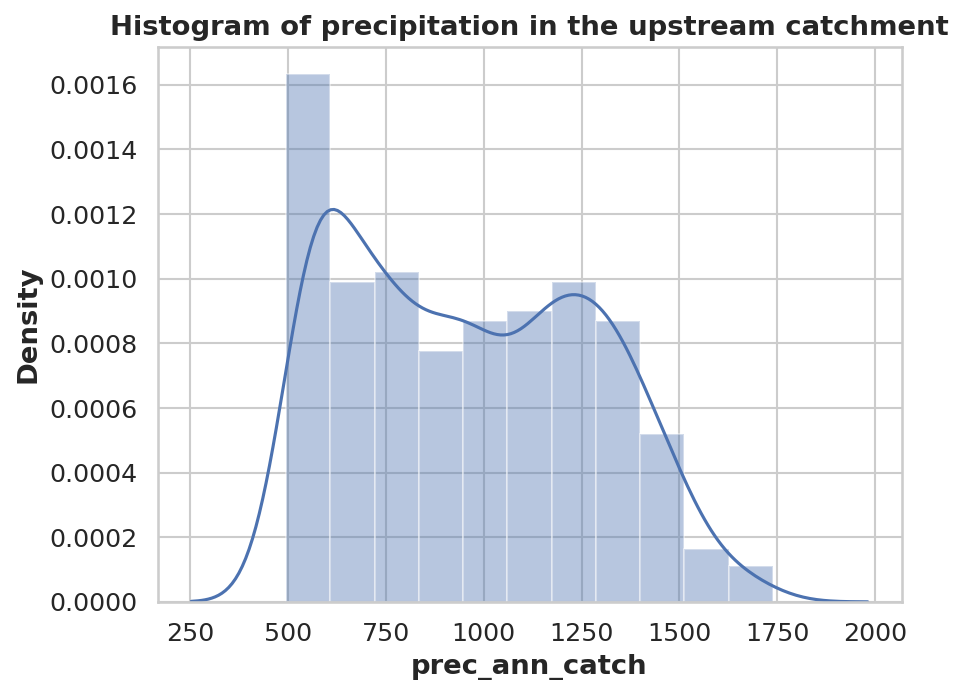

In [ ]:
# same thing but only for Portugal
df_port = df[df['Country']=='Portugal']

sns.histplot(
    df_port["prec_ann_catch"],
    kde=True,
    stat="density",
    kde_kws=dict(cut=3),
    alpha=.4,
    edgecolor=(1, 1, 1, 0.4),
).set_title("Histogram of precipitation in the upstream catchment")
plt.show()


### Violin plots

Check here: https://seaborn.pydata.org/generated/seaborn.violinplot.html

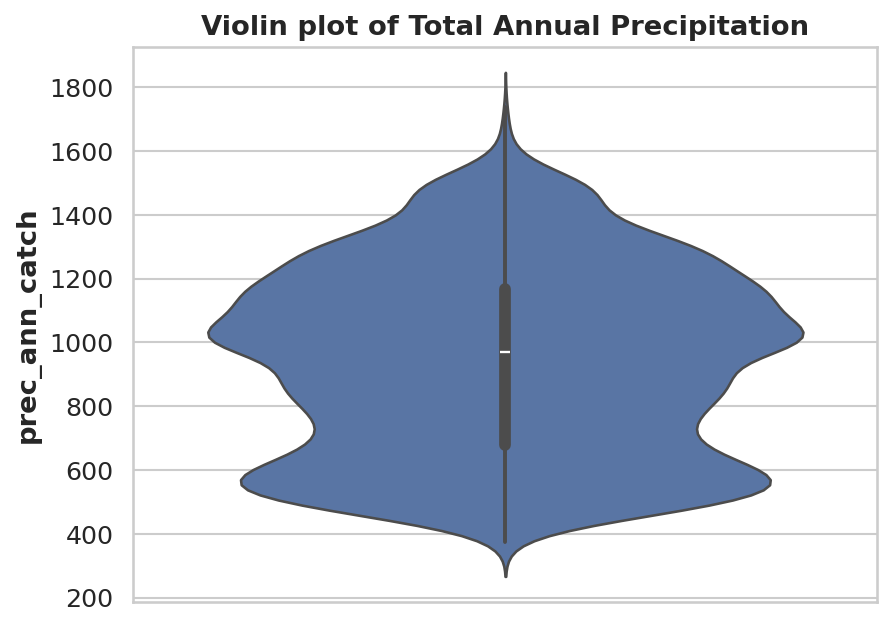

In [ ]:
# violin plot of Total Annual Precipitation by country
sns.violinplot(data=df, y="prec_ann_catch").set_title("Violin plot of Total Annual Precipitation")
plt.show()

### Raincloud plots

Raincloud plots combine violin plots, boxplots and strip plots into a single chart. To plot raincloud plots it is helpful to use the `ptitprince` library. You may need to install `ptitprince`by running `pip install ptitprince` in the terminal.

In [ ]:
!pip -q install ptitprince

In [ ]:
import ptitprince as pt

In [ ]:
help(pt.RainCloud)

Help on function RainCloud in module ptitprince.PtitPrince:

RainCloud(x: Union[pandas.core.series.Series, numpy.ndarray, list, NoneType] = None, y: Union[pandas.core.series.Series, numpy.ndarray, list, NoneType] = None, hue: Union[pandas.core.series.Series, numpy.ndarray, list, NoneType] = None, data: Optional[pandas.core.frame.DataFrame] = None, order: Optional[list[str]] = None, hue_order: Optional[list[str]] = None, orient: str = 'v', width_viol: float = 0.7, width_box: float = 0.15, palette: Union[str, list, dict, NoneType] = None, bw: Union[str, float] = 0.2, linewidth: float = 1, cut: float = 0.0, scale: str = 'area', jitter: bool = True, move: float = 0.0, offset: Optional[float] = None, point_size: float = 3, ax: Optional[matplotlib.axes._axes.Axes] = None, pointplot: bool = False, alpha: Optional[float] = None, dodge: bool = False, linecolor: str = 'red', **kwargs: Any) -> matplotlib.axes._axes.Axes
    Draw a Raincloud plot of measure `y` of different categories `x`.

    He

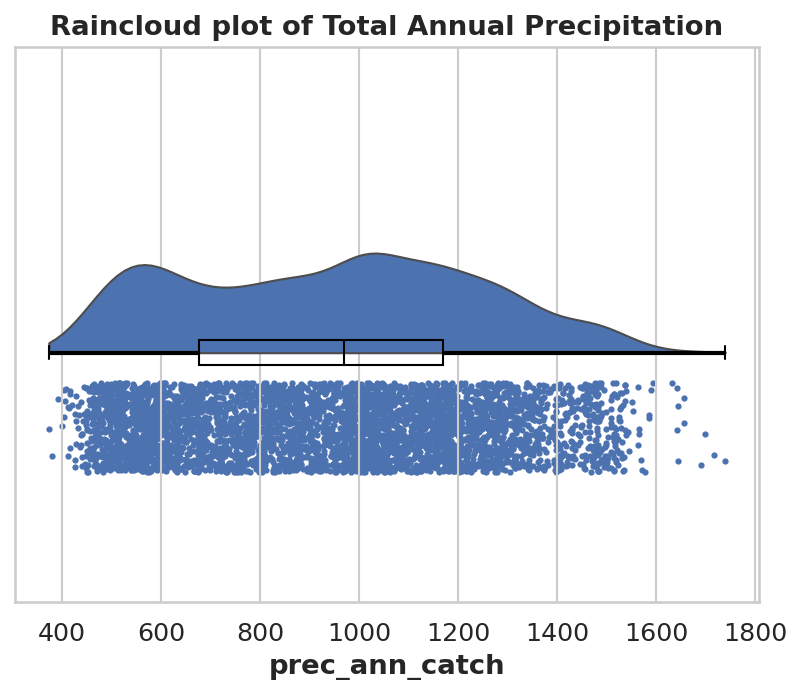

In [ ]:
# Raincloud plot of Total Annual Precipitation

pt.RainCloud(y="prec_ann_catch", data=df,
             bw=0.2, # defines h|ow smooth is the distribution curve of the violin plot (cloud)
             width_viol=0.4, # width of the half violin (cloud)
             width_box=0.05, # width of the box
             orient='h', # orientation
             move=0.15, # position of the strip plot
             offset=0,# relative position of the half violin (cloud) in relation to the boxplot
             jitter=0.09) # allows to define the width of the strip plot (rain)

plt.title("Raincloud plot of Total Annual Precipitation")
plt.show()

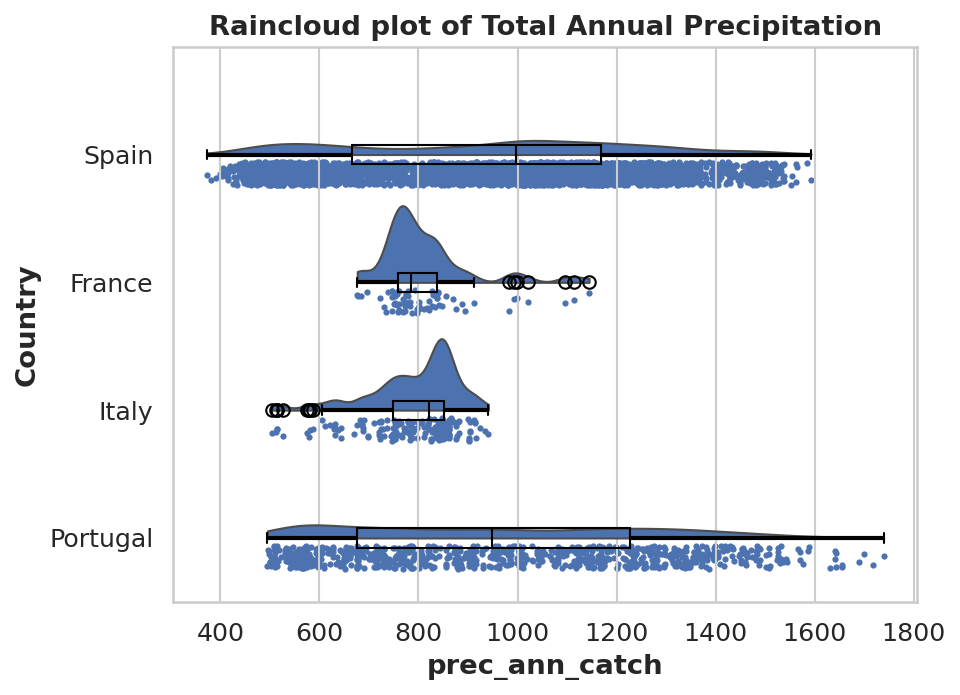

In [ ]:
# Raincloud plot of Total Annual Precipitation by country

pt.RainCloud(x='Country', y="prec_ann_catch", data=df,
             bw=0.2, # defines how smooth is the distribution curve of the violin plot (cloud)
             width_viol=1.2, # width of the half violin (cloud)
             width_box=0.15, # wdth of the box
             orient='h', # orientation
             move=0.15, #position of the strip plot
             offset=0,# relative position of the half violin (cloud) in relation to the boxplot
             jitter=0.09) # allows to define the width of the strip plot (rain)

plt.title("Raincloud plot of Total Annual Precipitation")
plt.show()

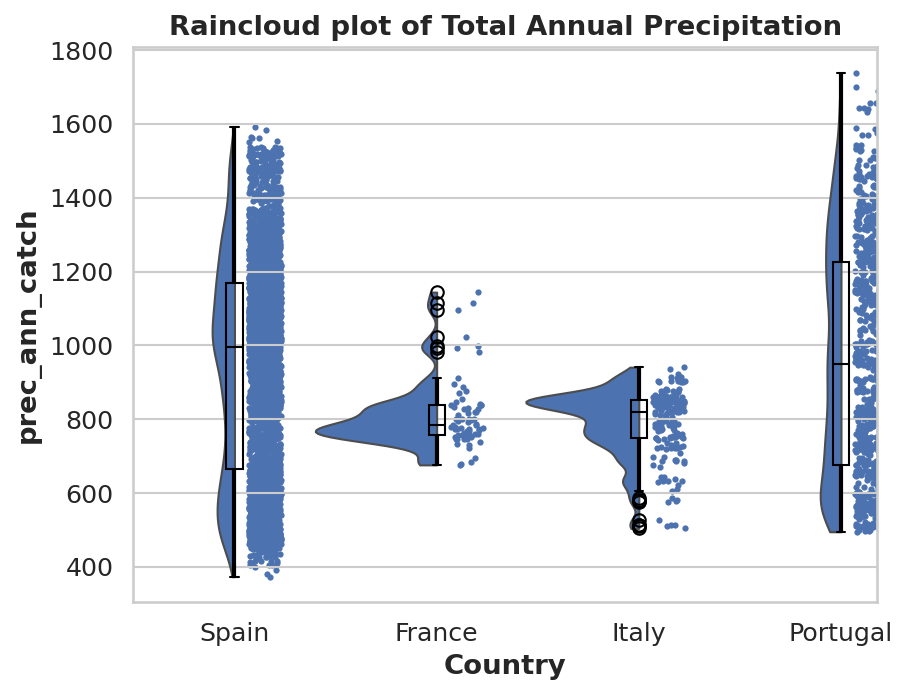

In [ ]:
# Vertical raincloud plot of Total Annual Precipitation by country

pt.RainCloud(x='Country', y="prec_ann_catch", data=df,
             bw=0.2, # defines how smooth is the distribution curve of the violin plot (cloud)
             width_viol=1.2, # width of the half violin (cloud)
             width_box=0.08, # wdth of the box
             move=0.15, #position of the strip plot
             offset=0,# relative position of the half violin (cloud) in relation to the boxplot
             jitter=0.08) # allows to define the width of the strip plot (rain)

plt.title("Raincloud plot of Total Annual Precipitation")
plt.show()

# Exercise 3

### Identifying the Top 4 Catchments by Number of Fish Sampling Sites

In [ ]:
# Count fish sampling sites per catchment
catchment_counts = df['Catchment_name'].value_counts()
top4_catchments = catchment_counts.head(4).index.tolist()

print("Top 4 catchments by number of fish sampling sites:")
for c in top4_catchments:
    print(f"  {c}: {catchment_counts[c]} sites")

# Subset for these 4 catchments
df_top4 = df2[df2['Catchment_name'].isin(top4_catchments)].copy()

Top 4 catchments by number of fish sampling sites:
  Ebro: 736 sites
  Galiza-Norte: 709 sites
  Minho: 707 sites
  Tejo: 509 sites


### Setting up the Global Plot Settings

As best practice in data visualization, it is important to set the theme for data visualization (style, color palette, etc).

Reference: [https://seaborn.pydata.org/tutorial/aesthetics.html](https://seaborn.pydata.org/tutorial/aesthetics.html)

In [ ]:
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
})

# Consistent colour palette for the 4 catchments
palette = dict(zip(top4_catchments, sns.color_palette("Set2", 4)))

### Strip Plot of Annual mean Temperature for the Top 4 Catchments

Columns in df_top4: Index(['Site_code', 'Latitude', 'Longitude', 'Country', 'Catchment_name',
       'Water_source_type', 'Flow_regime', 'Altitude', 'Geological_typology',
       'Actual_river_slope',
       ...
       'Squalius malacitanus', 'Squalius pyrenaicus', 'Squalius torgalensis',
       'Thymallus thymallus', 'Tinca tinca', 'Zingel asper', 'Squalius sp',
       'Barbatula sp', 'Phoxinus sp', 'Iberochondrostoma_sp'],
      dtype='object', length=154)


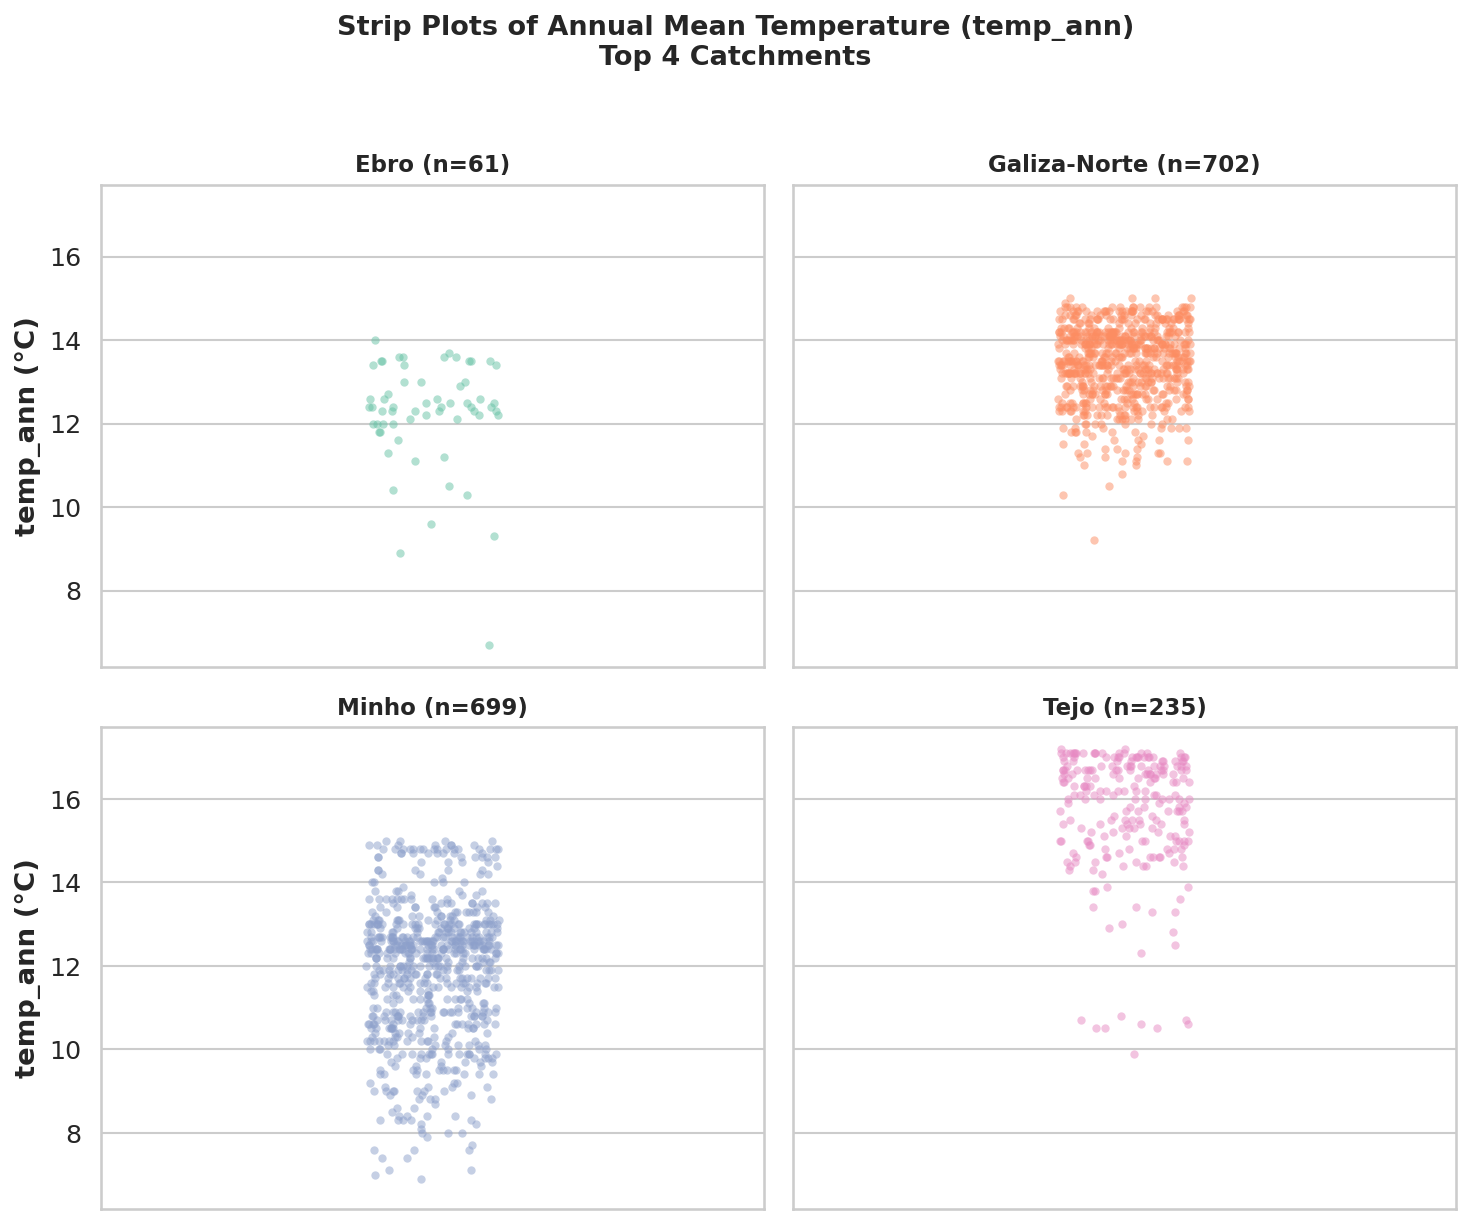

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
fig.suptitle("Strip Plots of Annual Mean Temperature (temp_ann)\nTop 4 Catchments",
             fontsize=13, fontweight='bold', y=1.02)

# Print columns for debugging
print("Columns in df_top4:", df_top4.columns)

for ax, catchment in zip(axes.flatten(), top4_catchments):
    data = df_top4[df_top4['Catchment_name'] == catchment]['temp_ann']
    sns.stripplot(y=data, ax=ax, color=palette[catchment],
                  jitter=True, alpha=0.5, size=4)
    ax.set_title(f"{catchment} (n={len(data)})", fontsize=11)
    ax.set_ylabel("temp_ann (°C)")
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

### Histogram with Kernel Density Estimation (KDE) of Annual mean Temperature for the Top 4 Catchments

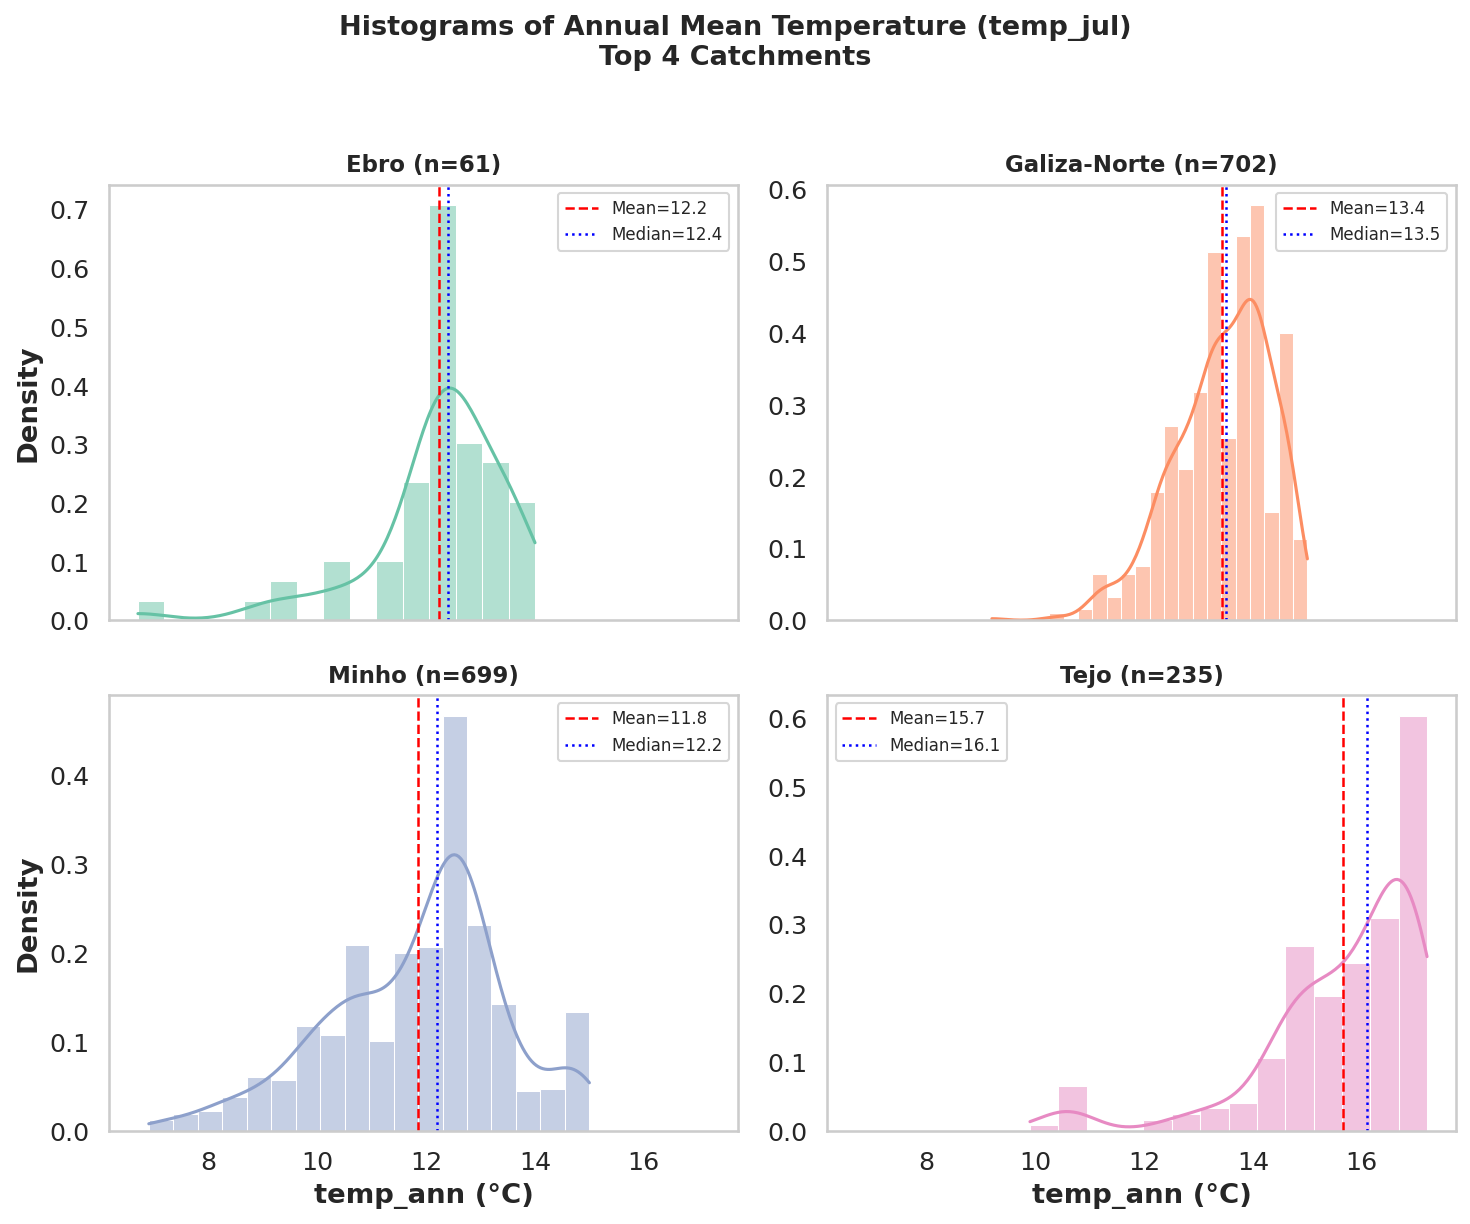

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
fig.suptitle("Histograms of Annual Mean Temperature (temp_jul)\nTop 4 Catchments",
             fontsize=13, fontweight='bold', y=1.02)

for i, (ax, catchment) in enumerate(zip(axes.flatten(), top4_catchments)):
    data = df_top4[df_top4['Catchment_name'] == catchment]['temp_ann']
    sns.histplot(data, kde=True, ax=ax, color=palette[catchment],
                 stat="density", alpha=0.5, edgecolor="white", linewidth=0.5)
    mean_val = data.mean()
    median_val = data.median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.2, label=f'Mean={mean_val:.1f}')
    ax.axvline(median_val, color='blue', linestyle=':', linewidth=1.2, label=f'Median={median_val:.1f}')
    ax.legend(fontsize=8)
    ax.set_title(f"{catchment} (n={len(data)})", fontsize=11)
    ax.grid(False)

    # X-label only on bottom row (indices 2 and 3)
    if i >= 2:
        ax.set_xlabel("temp_ann (°C)")
    else:
        ax.set_xlabel("")

    # Y-label only on left column (indices 0 and 2)
    if i % 2 == 0:
        ax.set_ylabel("Density")
    else:
        ax.set_ylabel("")

plt.tight_layout()
plt.show()

### Box Plots of Annual mean Temperature for the Top 4 Catchments

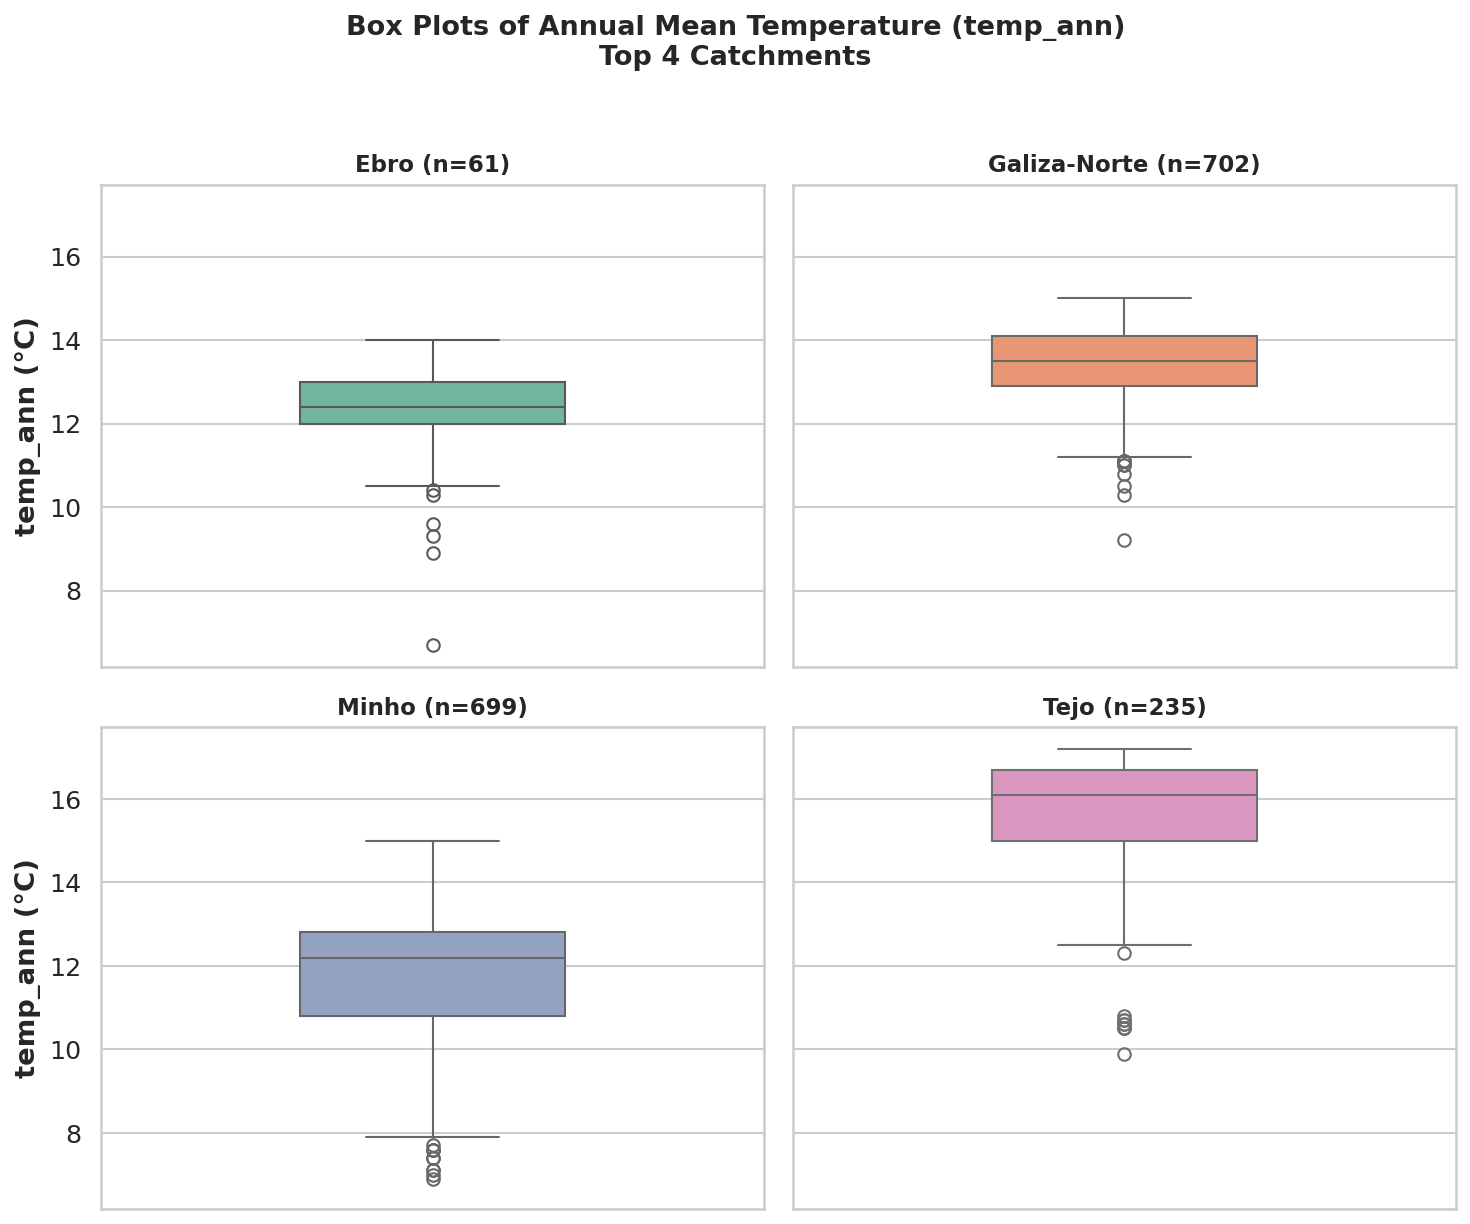

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
fig.suptitle("Box Plots of Annual Mean Temperature (temp_ann)\nTop 4 Catchments",
             fontsize=13, fontweight='bold', y=1.02)

for ax, catchment in zip(axes.flatten(), top4_catchments):
    data = df_top4[df_top4['Catchment_name'] == catchment]['temp_ann']
    sns.boxplot(y=data, ax=ax, color=palette[catchment], width=0.4)
    ax.set_title(f"{catchment} (n={len(data)})", fontsize=11)
    ax.set_ylabel("temp_ann (°C)")
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

### Violin Plots of Annual Mean Temperature

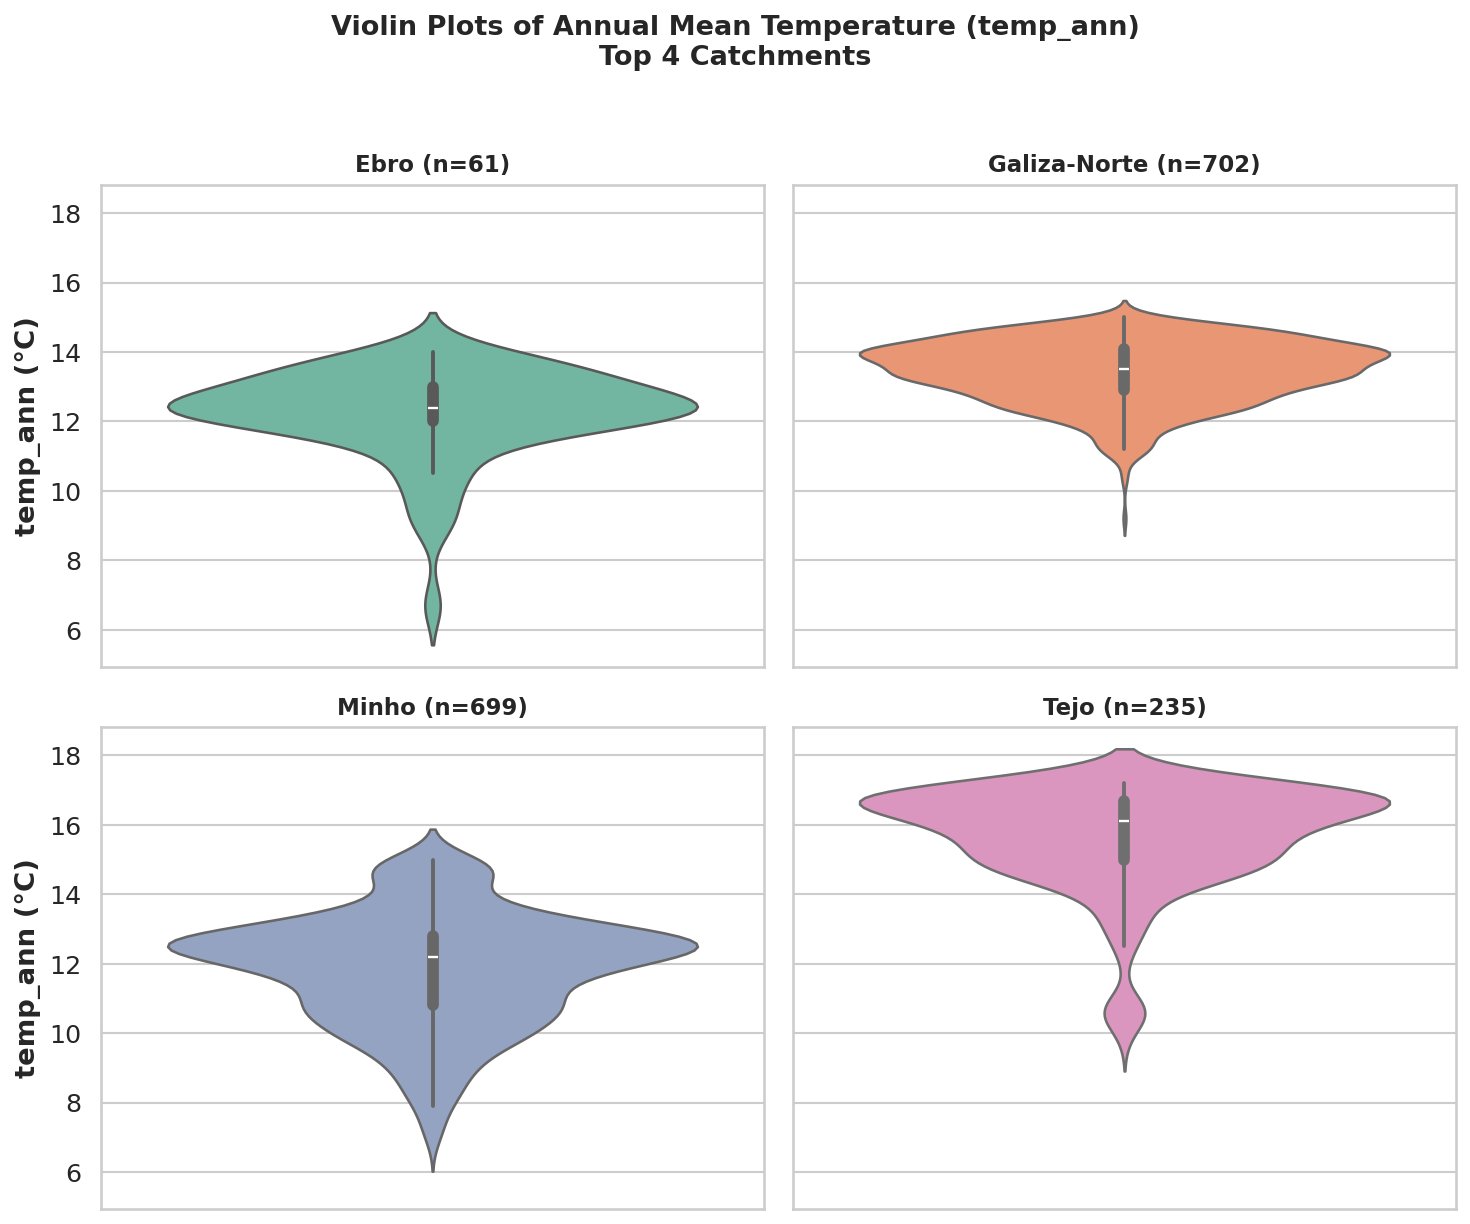

In [222]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
fig.suptitle("Violin Plots of Annual Mean Temperature (temp_ann)\nTop 4 Catchments",
             fontsize=13, fontweight='bold', y=1.02)

for ax, catchment in zip(axes.flatten(), top4_catchments):
    data = df_top4[df_top4['Catchment_name'] == catchment]['temp_ann']
    sns.violinplot(y=data, ax=ax, color=palette[catchment], inner="box")
    ax.set_title(f"{catchment} (n={len(data)})", fontsize=11)
    ax.set_ylabel("temp_ann (°C)")
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

### Sampling Distribution of Mean Annual Temperature



In [227]:
np.random.seed(42)
population = df2['temp_ann'].values
pop_mean = population.mean()
pop_std = population.std()
print(f"Population mean: {pop_mean:.4f} °C")
print(f"Population std:  {pop_std:.4f} °C")

sample_sizes = [10, 50, 100, 150, 200, 250, 300, 500, 1000, 1500]
n_samples = 1000

results = []
for size in sample_sizes:
    means = [np.mean(np.random.choice(population, size=size, replace=True))
             for _ in range(n_samples)]
    for m in means:
        results.append({'Sample Size': size, 'Sample Mean': m})

df_results = pd.DataFrame(results)

Population mean: 13.4315 °C
Population std:  1.9084 °C


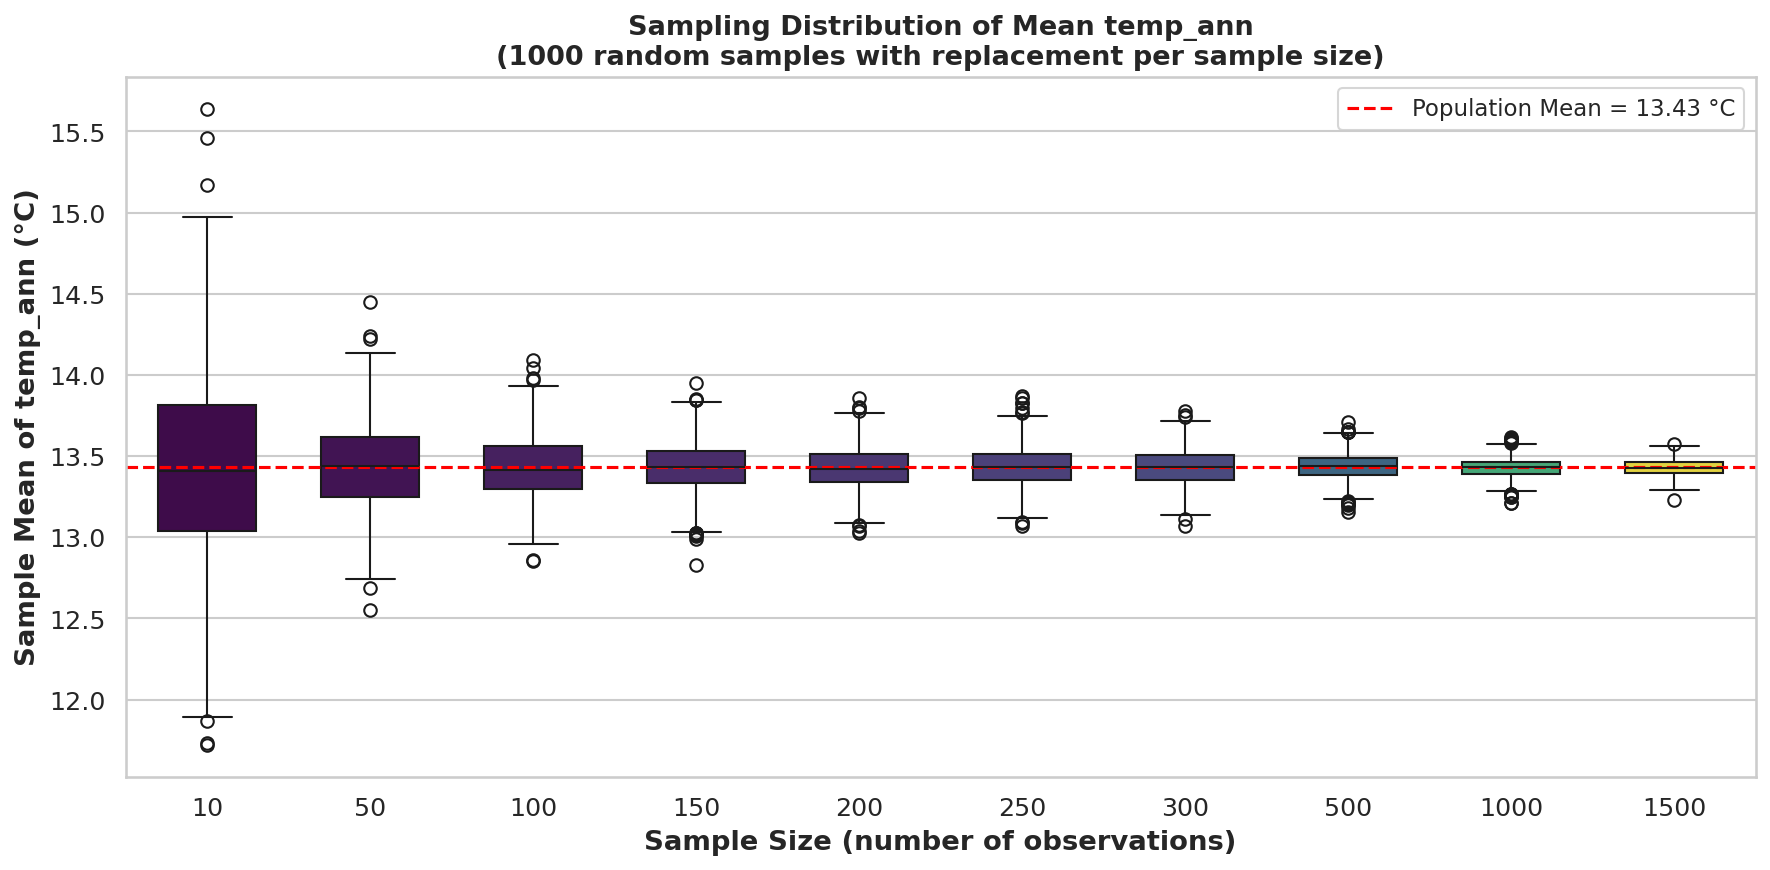

In [228]:
# Boxplot of sampling distributions at each sample size
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(x='Sample Size', y='Sample Mean', data=df_results, ax=ax,
            hue='Sample Size', palette='viridis', width=0.6, legend=False)
ax.axhline(pop_mean, color='red', linestyle='--', linewidth=1.5,
           label=f'Population Mean = {pop_mean:.2f} °C')
ax.set_title("Sampling Distribution of Mean temp_ann\n(1000 random samples with replacement per sample size)",
             fontweight='bold', fontsize=13)
ax.set_xlabel("Sample Size (number of observations)")
ax.set_ylabel("Sample Mean of temp_ann (°C)")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

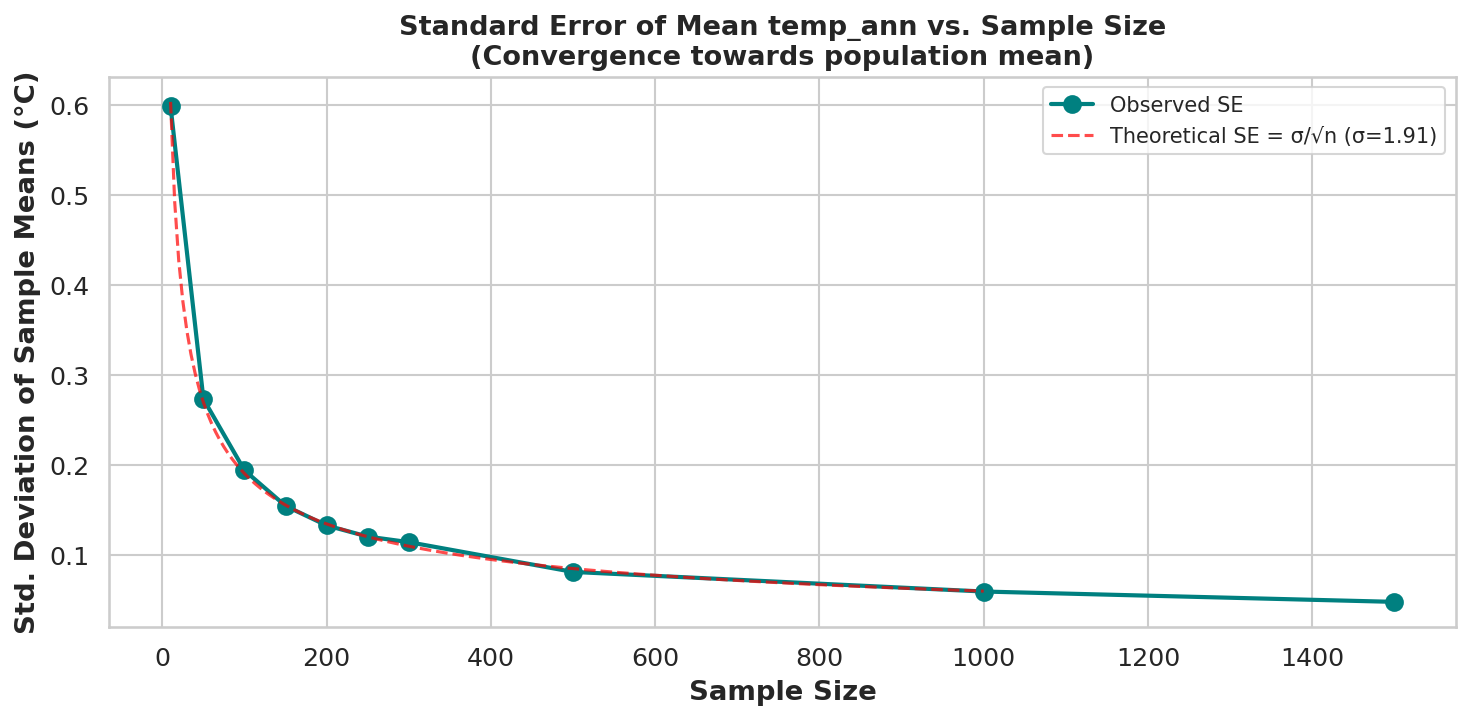

In [229]:
# Standard error convergence plot
fig, ax = plt.subplots(figsize=(10, 5))
std_per_size = df_results.groupby('Sample Size')['Sample Mean'].std().reset_index()
std_per_size.columns = ['Sample Size', 'Std of Sample Means']

ax.plot(std_per_size['Sample Size'], std_per_size['Std of Sample Means'],
        'o-', color='teal', linewidth=2, markersize=8, label='Observed SE')

# Theoretical SE curve
x_theory = np.linspace(10, 1000, 200)
ax.plot(x_theory, pop_std / np.sqrt(x_theory), '--', color='red', alpha=0.7,
        label=f'Theoretical SE = σ/√n (σ={pop_std:.2f})')

ax.set_title("Standard Error of Mean temp_ann vs. Sample Size\n(Convergence towards population mean)",
             fontweight='bold', fontsize=13)
ax.set_xlabel("Sample Size")
ax.set_ylabel("Std. Deviation of Sample Means (°C)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [230]:
from scipy import stats
Z_95 = stats.norm.ppf(0.975)  # 0.975 because 2.5% in each tail
print(Z_95)

1.959963984540054


In [231]:
import numpy as np

population = df2['temp_ann'].values
sigma = population.std()       # population standard deviation
e = 0.1                        # margin of error in °C (you choose this)

n = (Z_95**2 * sigma**2) / (e**2)
print(f"σ = {sigma:.4f} °C")
print(f"Required sample size (±{e} °C, 95% CI): {np.ceil(n).astype(int)}")

σ = 1.9084 °C
Required sample size (±0.1 °C, 95% CI): 1400
